##**Mengidentifikasi Pertanyaan Bisnis**

1.  Obat apa yang mempunyai volume penjualan tertinggi dan terendah dari tahun 2020-2025?
2.  Bagaimana tren penjualan obat dari 2020 hingga 2025?
3.  Apakah terdapat pola musiman dalam permintaan obat dari 2020 hingga 2025?
4.  Bagaimana distribusi permintaan obat terhadap faktor yang memengaruhi permintaan obat??
5.  Bagaimana distribusi permintaan obat di setiap region?

##**Import Library and Packages**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

**Insight:**

Disini kami melakukan import library yang dibutuhkan selama proses analisis data

##**Data Wrangling**

**1. Gathering Data**

In [2]:
data_df = pd.read_csv('dataset.csv')
data_df.head()

,date,year,month,day,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
0,1/1/2020,2020,1,1,South Asia,Sri Lanka,Antibiotic,Amoxicillin,46-65,731,78.28,4347,123,1
1,1/1/2020,2020,1,1,North America,Canada,Antibiotic,Amoxicillin,0-12,709,8.52,4475,168,1
2,1/1/2020,2020,1,1,Oceania,Australia,Antibiotic,Amoxicillin,46-65,408,89.33,4670,603,1
3,1/1/2020,2020,1,1,East Asia,Japan,Antibiotic,Amoxicillin,65+,687,34.05,4432,186,1
4,1/1/2020,2020,1,1,Middle East,UAE,Antibiotic,Amoxicillin,65+,659,14.78,4402,86,1


**Insight:**

Melakukan proses loading data dari file CSV ke dalam struktur DataFrame menggunakan library pandas lalu menampilkan 5 baris paling atas dari dataset

**2. Accesing Data**

In [3]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177990 entries, 0 to 177989
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   date                   177990 non-null  object 
 1   year                   177990 non-null  int64  
 2   month                  177990 non-null  int64  
 3   day                    177990 non-null  int64  
 4   region                 177990 non-null  object 
 5   country                177990 non-null  object 
 6   category               177990 non-null  object 
 7   medicine               177990 non-null  object 
 8   age_group              177990 non-null  object 
 9   units_sold             177990 non-null  int64  
 10  unit_price             177990 non-null  float64
 11  stock_level            177990 non-null  int64  
 12  expiry_days_remaining  177990 non-null  int64  
 13  covid_flag             177990 non-null  int64  
dtypes: float64(1), int64(7), object(6)
m

**Insight:**

Terlihat bahwa dataset memiliki 177,990 baris dan beberapa tipe data seperti int64, float64, dan object.
Semua kolom memiliki jumlah data yang sama (non-null), artinya tidak ada missing values.

In [4]:
a = data_df['year'].unique()
print (a)

b = data_df['month'].unique()
print(b)

c = data_df['day'].unique()
print(c)

d = data_df['region'].unique()
print(d)

e = data_df['country'].unique()
print(e)

f = data_df['medicine'].unique()
print(f)

g = data_df['age_group'].unique()
print (g)

h = data_df['covid_flag'].unique()
print (h)


[2020 2021 2022 2023 2024 2025]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31]
['South Asia' 'North America' 'Oceania' 'East Asia' 'Middle East' 'Europe'
 'Africa' 'South America']
['Sri Lanka' 'Canada' 'Australia' 'Japan' 'UAE' 'UK' 'Nigeria' 'Brazil'
 'China' 'Germany' 'New Zealand' 'Saudi Arabia' 'USA' 'Kenya' 'Bangladesh'
 'South Korea' 'France' 'Argentina' 'India']
['Amoxicillin' 'Paracetamol' 'Ibuprofen' 'Cough Syrup' 'Cetirizine'
 'Amlodipine' 'Azithromycin' 'Vitamin C' 'Multivitamin' 'Metformin']
['46-65' '0-12' '65+' '26-45' '13-25']
[1 0]


**Insight:**

Memahami distribusi dari nilai dalam tiap kolom dan memastikan data konsisten serta lengkap sebelum proses analisis lebih lanjut

In [5]:
# Mencari duplikasi
print("Jumlah duplikasi:", data_df.duplicated().sum())

# Mencari missing values
data_df.isna().sum()

Jumlah duplikasi: 2630


date                     0
year                     0
month                    0
day                      0
region                   0
country                  0
category                 0
medicine                 0
age_group                0
units_sold               0
unit_price               0
stock_level              0
expiry_days_remaining    0
covid_flag               0
dtype: int64

**Insight:**

Kode ini digunakan untuk melakukan pengecekan pada dataset apakah memiliki duplikasi dan missing values

In [6]:
#cek nilai yang tidak masuk akal
a = (
    (data_df['units_sold'] < 0) |
    (data_df['unit_price'] <= 0) |
    (data_df['stock_level'] < 0) |
(data_df['expiry_days_remaining'] < 0)
).sum()


print("Jumlah nilai yang tidak masuk akal:", a)


Jumlah nilai yang tidak masuk akal: 0


**Insight:**

 Kode ini digunakan untuk mengecek apakah ada nilai yang tidak masuk akal (invalid) pada beberapa kolom penting. Outputnya adalah 0, artinya tidak ada data aneh atau tidak valid di kolom-kolom tersebut. Jadi, data sudah cukup bersih dan logis untuk dianalisis lebih lanjut.

In [7]:
data_df.describe()

,year,month,day,units_sold,unit_price,stock_level,expiry_days_remaining,covid_flag
count,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000,177990.000000
mean,2022.499702,6.521754,15.730457,447.913849,52.554729,4552.991780,374.038109,0.333519
std,1.708113,3.448703,8.801170,338.924528,27.421909,346.608511,199.759193,0.471471
min,2020.000000,1.000000,1.000000,31.000000,5.000000,0.000000,30.000000,0.000000
25%,2021.000000,4.000000,8.000000,284.000000,28.770000,4443.000000,200.000000,0.000000
50%,2023.000000,7.000000,16.000000,387.000000,52.600000,4598.000000,374.000000,0.000000
75%,2024.000000,10.000000,23.000000,529.000000,76.310000,4735.000000,547.000000,1.000000
max,2025.000000,12.000000,31.000000,8704.000000,100.000000,5124.000000,720.000000,1.000000


**Insight:**

Menampilkan ringkasan statistik untuk kolom numerik. Ini membantu memahami sebaran data, nilai rata-rata, serta potensi outlier sebelum analisis lebih dalam

**3. Cleaning Data**

In [8]:
# Menghapus Kolom Day dan Covid_flag
data_df = data_df.drop(columns=['day', 'covid_flag'], errors='ignore')

**Insight:**

Variabel `day` dihapus karena analisis difokuskan pada level bulanan sehingga data harian tidak relevan, sedangkan `covid_flag` dihapus karena tidak digunakan dalam analisis dan tidak memberikan kontribusi langsung terhadap tujuan penelitian.

In [9]:
#mengganti format date (object) menjadi date time
data_df['date'] = pd.to_datetime(data_df['date'])

#menghapus duplikasi
data_df = data_df.drop_duplicates()

# Mengecek jumlah duplikasi setelah dilakukan penghapusan data duplikat
print("Jumlah duplikasi:", data_df.duplicated().sum())

#menambahkan nama bulan
bulan_dict = {
    1: 'Januari',
    2: 'Februari',
    3: 'Maret',
    4: 'April',
    5: 'Mei',
    6: 'Juni',
    7: 'Juli',
    8: 'Agustus',
    9: 'September',
    10: 'Oktober',
    11: 'November',
    12: 'Desember'
}

#replace month column jadi nama bulan
data_df['month'] = data_df['month'].map(bulan_dict)

#rapihin kolom kategori (upper dan lower sama)
cols = ['region', 'country', 'category', 'medicine', 'age_group']
data_df[cols] = data_df[cols].apply(lambda x: x.str.strip().str.title())

data_df.head()

Jumlah duplikasi: 0


,date,year,month,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining
0,2020-01-01,2020,Januari,South Asia,Sri Lanka,Antibiotic,Amoxicillin,46-65,731,78.28,4347,123
1,2020-01-01,2020,Januari,North America,Canada,Antibiotic,Amoxicillin,0-12,709,8.52,4475,168
2,2020-01-01,2020,Januari,Oceania,Australia,Antibiotic,Amoxicillin,46-65,408,89.33,4670,603
3,2020-01-01,2020,Januari,East Asia,Japan,Antibiotic,Amoxicillin,65+,687,34.05,4432,186
4,2020-01-01,2020,Januari,Middle East,Uae,Antibiotic,Amoxicillin,65+,659,14.78,4402,86


**Insight:**

**Kode ini melakukan tahap data cleaning dan formatting agar data lebih rapi dan siap dianalisis. Beberapa proses yang dilakukan:**

1. Mengubah kolom **date** ke format **datetime** supaya bisa dianalisis berbasis waktu.
2. Menghapus **data duplikat** agar hasil analisis tidak bias.
3. Mengecek kembali **jumlah data duplikasi** untuk memastikan bahwa data sudah bersih dari duplikasi
4. Mengganti **angka pada kolom month** menjadi **nama bulan** agar lebih mudah dibaca.
5. Merapikan teks pada kolom **kategori (seperti region, country, dll)** dengan format yang konsisten (huruf kapital di awal, tanpa spasi berlebih).

In [10]:
data_df.describe()

,date,year,units_sold,unit_price,stock_level,expiry_days_remaining
count,175360,175360.000000,175360.000000,175360.000000,175360.000000,175360.000000
mean,2022-12-31 12:00:00,2022.499544,447.847765,52.551273,4553.132619,374.138487
min,2020-01-01 00:00:00,2020.000000,31.000000,5.000000,0.000000,30.000000
25%,2021-07-01 18:00:00,2021.000000,284.000000,28.780000,4443.000000,200.000000
50%,2022-12-31 12:00:00,2022.500000,387.000000,52.610000,4598.000000,374.000000
75%,2024-07-01 06:00:00,2024.000000,528.000000,76.290000,4735.000000,547.000000
max,2025-12-31 00:00:00,2025.000000,8704.000000,100.000000,5124.000000,720.000000
std,NaN,1.708186,338.887291,27.416471,346.422890,199.771560


# **Exploratory Data Analysis**

**Explore Pharmacy Dataset**

Bagian ini merupakan tahap Exploratory Data Analysis (EDA), yaitu proses untuk mengeksplorasi data guna menemukan pola, hubungan, dan insight yang relevan dengan **pertanyaan bisnis**

In [11]:
data_df.describe(include="all")

,date,year,month,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining
count,175360,175360.000000,175360,175360,175360,175360,175360,175360,175360.000000,175360.000000,175360.000000,175360.000000
unique,NaN,NaN,12,8,19,5,10,5,NaN,NaN,NaN,NaN
top,NaN,NaN,Januari,South Asia,Brazil,Antibiotic,Amoxicillin,46-65,NaN,NaN,NaN,NaN
freq,NaN,NaN,14880,21920,11163,35072,17536,35369,NaN,NaN,NaN,NaN
mean,2022-12-31 12:00:00,2022.499544,NaN,NaN,NaN,NaN,NaN,NaN,447.847765,52.551273,4553.132619,374.138487
min,2020-01-01 00:00:00,2020.000000,NaN,NaN,NaN,NaN,NaN,NaN,31.000000,5.000000,0.000000,30.000000
25%,2021-07-01 18:00:00,2021.000000,NaN,NaN,NaN,NaN,NaN,NaN,284.000000,28.780000,4443.000000,200.000000
50%,2022-12-31 12:00:00,2022.500000,NaN,NaN,NaN,NaN,NaN,NaN,387.000000,52.610000,4598.000000,374.000000
75%,2024-07-01 06:00:00,2024.000000,NaN,NaN,NaN,NaN,NaN,NaN,528.000000,76.290000,4735.000000,547.000000
max,2025-12-31 00:00:00,2025.000000,NaN,NaN,NaN,NaN,NaN,NaN,8704.000000,100.000000,5124.000000,720.000000


**Insight:**

Melihat ringkasan statistik. Hal ini membantu memahami sebaran data, nilai rata-rata, serta potensi outlier sebelum analisis

**1. Explore Medicine, Unit Sold, Year**

In [12]:
# Agregasi total penjualan per medicine (2020–2025)
df_group = data_df.groupby('medicine').agg({
    'units_sold': 'sum'
}).reset_index()

# Hitung rata-rata total penjualan semua medicine
mean_all = df_group['units_sold'].mean()

# Klasifikasi fast moving / slow moving
df_group['kategori'] = df_group['units_sold'].apply(
    lambda x: 'Fast Moving' if x > mean_all else 'Slow Moving'
)

# Urutkan berdasarkan total penjualan
df_sorted = df_group.sort_values('units_sold', ascending=False)

# Ambil top 5 dan bottom 5
top = df_sorted.head(5)[['medicine', 'units_sold', 'kategori']]
bottom = df_sorted.tail(5)[['medicine', 'units_sold', 'kategori']]

# Tampilkan hasil
print("Top 5 Obat Terlaris 2020–2025:")
print(top)

print("\nBottom 5 Obat Tidak Laris 2020–2025:")
print(bottom)

Top 5 Obat Terlaris 2020–2025:
       medicine  units_sold     kategori
2  Azithromycin     7896771  Fast Moving
8   Paracetamol     7892260  Fast Moving
7  Multivitamin     7869649  Fast Moving
5     Ibuprofen     7867488  Fast Moving
6     Metformin     7865048  Fast Moving

Bottom 5 Obat Tidak Laris 2020–2025:
      medicine  units_sold     kategori
9    Vitamin C     7858526  Fast Moving
4  Cough Syrup     7847488  Slow Moving
3   Cetirizine     7831986  Slow Moving
0   Amlodipine     7822352  Slow Moving
1  Amoxicillin     7783016  Slow Moving


**Insight:**

**Kode ini digunakan untuk mengetahui volumen penjualan obat dari tahun 2020 - 2025, hal yang dilakukan pada kode ini adalah:**

1. Agregasi total penjualan per medicine untuk mengetahui jumlah permintaan obat selama 2020 hingga 2025
2. Hitung rata - rata total penjualan semua obat
3. Mengklasifikasikan jenis obat yang memiliki penjualan lebih dari rata - rata akan di kategorikan fast moving, sebaliknya jika permintaan obat kurang dari rata - rata maka akan di kategorikan sebagai obat slow moving
4. Mangurutkan obat berdasarkan total penjualan dari yang tertinggi hingga terendah
5. Menampilkan hasil pengurutan untuk melihat pola permintaan obat tertinggi dan terendah

**2. Explore Medicine, Year, Unit Sold**

In [13]:
# Agregasi total penjualan per obat per tahun
trend_med = (
    data_df.groupby(['medicine', 'year'], as_index=False)['units_sold']
    .sum()
)

# Mengurutkan nama obat bedasarkan abjad dan mulai dari tahun 2020
trend_med = trend_med.sort_values(['medicine', 'year']).reset_index(drop=True)

# Hitung perubahan atau selisih tahun sebelumnya untuk setiap permintaan obat
trend_med['change'] = trend_med.groupby('medicine')['units_sold'].diff()

# Hitung persentase perubahan dibanding tahun sebelumnya untuk setiap obat
trend_med['growth_%'] = trend_med.groupby('medicine')['units_sold'].pct_change() * 100

# Buat label status tren untuk mengetahui distribusi obat dari tahun 2020-2025
def trend_status(change):
    if pd.isna(change):
        return 'Tahun awal'
    elif change > 0:
        return 'Naik'
    elif change < 0:
        return 'Turun'
    else:
        return 'Tetap'
# Menambahkan kolomm trend status untuk memberi gambaran terkait pola distribusi permintaan obat
trend_med['trend_status'] = trend_med['change'].apply(trend_status)

# Rapikan angka growth dengan mengambil 2 angka dibelakang koma agar lebih mudah untuk dibaca
trend_med['growth_%'] = trend_med['growth_%'].round(2)

# Tampilkan hasil lengkap
print("Tabel Tren Penjualan per Obat per Tahun:")
print(trend_med)


Tabel Tren Penjualan per Obat per Tahun:
        medicine  year  units_sold    change  growth_% trend_status
0     Amlodipine  2020     1727508       NaN       NaN   Tahun awal
1     Amlodipine  2021     1765203   37695.0      2.18         Naik
2     Amlodipine  2022     1078198 -687005.0    -38.92        Turun
3     Amlodipine  2023     1086076    7878.0      0.73         Naik
4     Amlodipine  2024     1097967   11891.0      1.09         Naik
5     Amlodipine  2025     1067400  -30567.0     -2.78        Turun
6    Amoxicillin  2020     1722877       NaN       NaN   Tahun awal
7    Amoxicillin  2021     1703018  -19859.0     -1.15        Turun
8    Amoxicillin  2022     1083626 -619392.0    -36.37        Turun
9    Amoxicillin  2023     1091530    7904.0      0.73         Naik
10   Amoxicillin  2024     1089158   -2372.0     -0.22        Turun
11   Amoxicillin  2025     1092807    3649.0      0.34         Naik
12  Azithromycin  2020     1749784       NaN       NaN   Tahun awal
13  Azi

**Inisght:**

Kode ini digunakan untuk mengidentifikasi obat paling laris dan paling tidak laris tiap tahun


**3. Explore Demand dan Month**

In [14]:
# Agregasi demand per bulan (angka 1–12)
monthly_demand = data_df.groupby(data_df['date'].dt.month)['units_sold'].sum().reset_index()

# Rename kolom bulan menjadi month number agar lebih mudah kami untuk menganalisa
monthly_demand.columns = ['month_num', 'units_sold']

# Ubah kolom month menjadi nama bulan
monthly_demand['month'] = monthly_demand['month_num'].apply(
    lambda x: pd.to_datetime(str(x), format='%m').strftime('%B')
)

# Hitung mean dari permintaan obat bedasarkan bulan
mean_demand = monthly_demand['units_sold'].mean()

# Memberi keterangan naik / turun terhadap mean. Jika lebih tinggi dari mean maka distribusi naik dan jika lebih rendah dari mean maka distribusi turun
monthly_demand['keterangan'] = monthly_demand['units_sold'].apply(
    lambda x: 'Naik' if x > mean_demand else 'Turun'
)

# Menambahkan kolom persenrase untuk mempermudah pemahaman kami dalam menganalisa
monthly_demand['persentase_perubahan'] = monthly_demand['units_sold'].pct_change() * 100

# Membuat kolom persentase perubahan lebih rapi dan memunculkan 2 angka di belakang koma
monthly_demand['persentase_perubahan'] = monthly_demand['persentase_perubahan'].round(2).astype(str) + '%'

monthly_demand

,month_num,units_sold,month,keterangan,persentase_perubahan
0,1,7848747,January,Naik,nan%
1,2,7941982,February,Naik,1.19%
2,3,8982426,March,Naik,13.1%
3,4,8486167,April,Naik,-5.52%
4,5,7788156,May,Naik,-8.23%
5,6,6503034,June,Turun,-16.5%
6,7,5516091,July,Turun,-15.18%
7,8,4631415,August,Turun,-16.04%
8,9,4207651,September,Turun,-9.15%
9,10,4634775,October,Turun,10.15%


**Insight:**

Permintaan obat menunjukkan pola musiman yang cukup jelas, di mana penjualan meningkat dari Januari hingga mencapai puncaknya pada bulan Maret, kemudian mengalami penurunan secara bertahap hingga mencapai titik terendah pada bulan September. Setelah itu, permintaan kembali meningkat pada periode Oktober hingga Desember. Pola ini mengindikasikan adanya tren penurunan di pertengahan tahun dan peningkatan kembali di akhir tahun, yang dapat dimanfaatkan sebagai dasar dalam analisis dan pengembangan model prediksi.

**4. Explore unit sold dengan semua kolom yang menjadi faktor permintaan obat**

In [15]:
# 1. Copy data
df_analysis = data_df.copy()

# Binning variabel numerik
df_analysis['price_group'] = pd.cut(
    df_analysis['unit_price'],
    bins=5,
    labels=[
        'Sangat Murah', # pengelompokkaan harga
        'Murah',
        'Sedang',
        'Mahal',
        'Sangat Mahal'
    ]
)

df_analysis['expiry_group'] = pd.cut(
    df_analysis['expiry_days_remaining'],
    bins=[0, 30, 90, 180, 365, df_analysis['expiry_days_remaining'].max()],
    labels=[
        '<30 Hari', # pengelompokkan sisa masa expired
        '30-90 Hari',
        '90-180 Hari',
        '180-365 Hari',
        '>365 Hari'
    ],
    include_lowest=True
)

# Daftar faktor yang akan diuji untuk mengetahui apa yang paling berpengaruh terhadap permintaan obat
factors = [
    'region',
    'country',
    'category',
    'medicine',
    'age_group',
    'price_group',
    'expiry_group'
]

# Hitung variasi permintaan obat per faktor
hasil_pengaruh = []

for factor in factors:
    grouped = df_analysis.groupby(factor)['units_sold'].mean()

    hasil_pengaruh.append({
        'factor': factor,                                 # menampilkan nama faktor
        'mean_max': round(grouped.max(), 2),              # menampilkan mean tertinggi
        'mean_min': round(grouped.min(), 2),              # menampilkan mean terendah
        'range': round(grouped.max() - grouped.min(), 2), # menampilkan selisih min dan max dari mean
        'std_dev': round(grouped.std(), 2)
    })

# Ranking faktor dari yang paling tinggi hingga rendah
pengaruh_df = pd.DataFrame(hasil_pengaruh)\
    .sort_values('range', ascending=False)\
    .reset_index(drop=True)

# Menampilkan hasil output
print("Ranking Faktor yang Memengaruhi Permintaan Obat (2020–2025)\n")
display(pengaruh_df)

Ranking Faktor yang Memengaruhi Permintaan Obat (2020–2025)



C:\Users\Raissa Yasmin S\AppData\Local\Temp\ipykernel_20436\4083821190.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_analysis.groupby(factor)['units_sold'].mean()


,factor,mean_max,mean_min,range,std_dev
0,country,452.53,442.86,9.67,2.72
1,medicine,450.32,443.83,6.49,1.94
2,region,449.33,444.07,5.26,1.89
3,price_group,450.95,446.81,4.14,1.76
4,expiry_group,449.70,446.37,3.33,1.22
5,category,449.35,447.07,2.29,1.02
6,age_group,449.12,446.92,2.20,0.96


**Insight:**

Untuk menjawab pertanyaan nomer 4, perlu dilakukan analisis mengenai semua faktor yang ada (country, region, dll) untuk di cari mana yang paling pengaruh dengan permintaan obat (unit sold). Analisis ini dilakukan untuk mengoptimalkan pengelolaan stok berdasarkan karakteristik pasar.

Penghitungan dilakukan dengan membandingkan rata-rata permintaan obat pada setiap kategori dalam masing-masing faktor, kemudian mengukur tingkat variasinya menggunakan range dan standar deviasi. Faktor dengan variasi rata-rata permintaan terbesar dianggap sebagai faktor yang paling berpengaruh terhadap perubahan permintaan obat.

**5. Explore Region dan Unit Sold**

In [16]:
# Agregasi reguion dan unit sold untuk menampilkan jumlah dan rata - rata
region_demand = data_df.groupby('region')['units_sold'].agg(['sum','mean']).reset_index()

# Menambahkan tabel region demand column dengan 3 kolom yang akan ditampilkan
region_demand.columns = ['region', 'total_units_sold', 'mean_units_sold']

# Hitung persentase dari permintaan obat
total_all = region_demand['total_units_sold'].sum()
region_demand['persentase_kontribusi'] = (region_demand['total_units_sold'] / total_all) * 100

# Memberi peringkat dari region mana yang paling tinggi persentase kontribusinya
region_demand['rank'] = region_demand['total_units_sold'].rank(ascending=False, method='dense').astype(int)

# Menambahkan format persen pada kolom persentase kontribusi
region_demand['persentase_kontribusi'] = region_demand['persentase_kontribusi'].round(2).astype(str) + '%'

# Membuat hasil urut berdasarkan rank
region_demand = region_demand.sort_values('rank')

region_demand

,region,total_units_sold,mean_units_sold,persentase_kontribusi,rank
3,Middle East,9849229,449.326141,12.54%,1
5,Oceania,9847959,449.268203,12.54%,2
7,South Asia,9844922,449.129653,12.54%,3
6,South America,9838549,448.838914,12.53%,4
1,East Asia,9837720,448.801095,12.53%,5
4,North America,9799919,447.076597,12.48%,6
2,Europe,9782351,446.275137,12.46%,7
0,Africa,9733935,444.066378,12.39%,8


**Insight:**

Distribusi penjualan obat berdasarkan region menunjukkan bahwa kontribusi tiap wilayah relatif merata, dengan persentase berkisar antara 12.39% hingga 12.54%. Middle East, Oceania, dan South Asia menjadi region dengan kontribusi tertinggi, meskipun perbedaannya tidak signifikan dibandingkan wilayah lain. Sementara itu, Africa memiliki kontribusi terendah.

##**Visualization and Explanatory**

**Pertanyaan 1 : obat apa yang memiliki volume penjualan tertinggi dan terendah**

C:\Users\Raissa Yasmin S\AppData\Local\Temp\ipykernel_20436\3346566561.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


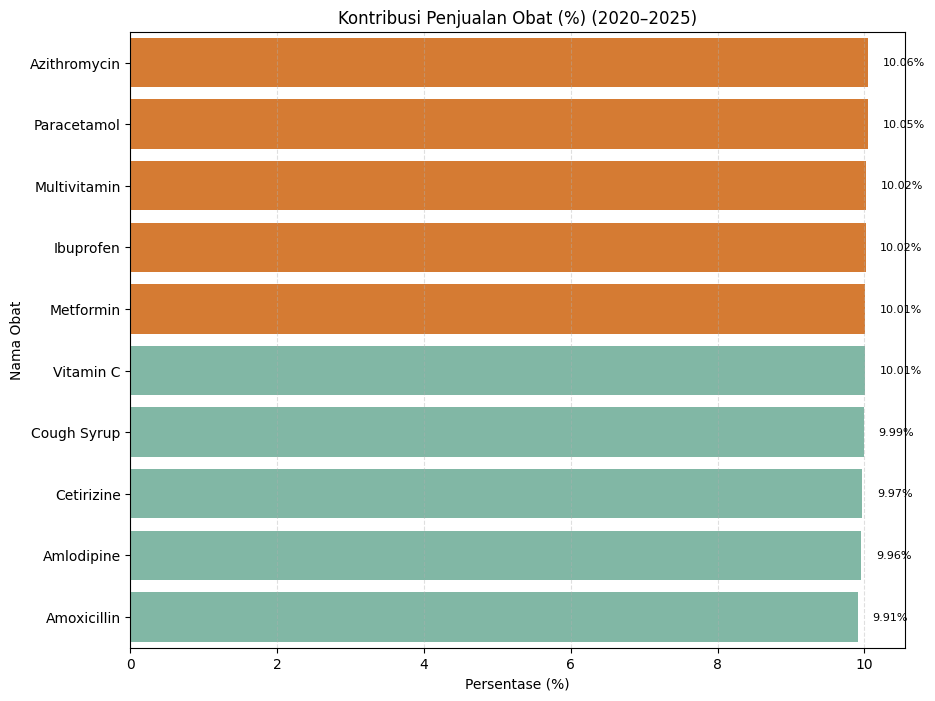

In [17]:
# Mengurutkan data berdasarkan jumlah unit terjual dari yang terbesar ke terkecil
df_sorted = df_group.sort_values('units_sold', ascending=False).reset_index(drop=True)

# Menghitung total semua unit obat yang terjual
total = df_sorted['units_sold'].sum()

# Menghitung persentase kontribusi penjualan tiap obat terhadap total penjualan
df_sorted['percentage'] = (df_sorted['units_sold'] / total) * 100

# Menentukan warna untuk setiap bar pada grafik
colors = []

# Memberi warna berbeda untuk Top 5, Bottom 5, dan data lainnya
for i in range(len(df_sorted)):
    if i < 5:
        colors.append('#F07818')  # Warna oranye untuk 5 obat dengan penjualan tertinggi
    elif i >= len(df_sorted) - 5:
        colors.append('#78C0A8')  # Warna hijau untuk 5 obat dengan penjualan terendah
    else:
        colors.append('#bdc3c7')  # Warna abu-abu untuk obat lainnya

# Membuat ukuran gambar grafik
plt.figure(figsize=(10,8))

# Membuat grafik bar horizontal dengan persentase sebagai sumbu X dan nama obat sebagai sumbu Y
ax = sns.barplot(
    data=df_sorted,
    x='percentage',
    y='medicine',
    palette=colors
)

# Menambahkan label persentase di sebelah kanan setiap bar
for i, v in enumerate(df_sorted['percentage']):
    ax.text(v + 0.2, i, f'{v:.2f}%', va='center', fontsize=8)

# Memberikan judul grafik
plt.title('Kontribusi Penjualan Obat (%) (2020–2025)', fontsize=12)

# Memberikan label pada sumbu X
plt.xlabel('Persentase (%)')

# Memberikan label pada sumbu Y
plt.ylabel('Nama Obat')

# Menambahkan garis bantu/grid pada sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.4)

# Menampilkan grafik
plt.show()

**Conclusion:**

Grafik ini Grafik ini menunjukkan distribusi penjualan seluruh obat selama periode 2020 hingga 2025, yang bertujuan untuk melihat kontribusi masing-masing obat terhadap total penjualan dan mengidentifikasi obat dengan permintaan tertinggi dan terendah.  

Obat yang memiliki volume penjualan tertinggi adalah Azithromicyn dan obat dengan penjualan terendah adalah amoxicilin. Persentase kontribusi penjualan, terlihat bahwa distribusi antar obat relatif merata (sekitar 9.97% – 10.06%). Hal ini menunjukkan bahwa meskipun terdapat perbedaan antara obat terlaris dan tidak laris, secara keseluruhan tidak ada satu obat yang benar-benar mendominasi pasar secara ekstrem.

**Pertanyaan 2 : Bagaimana tren penjualan obat dari waktu ke waktu?**

In [18]:
# Mengelompokkan data berdasarkan nama obat dan tahun, lalu menjumlahkan total unit terjual
trend_med = (
    data_df.groupby(['medicine', 'year'], as_index=False)['units_sold']
    .sum()
)

# Mengurutkan data berdasarkan nama obat dan tahun agar tren tiap obat tersusun rapi
trend_med = trend_med.sort_values(['medicine', 'year']).reset_index(drop=True)

# Menghitung selisih penjualan dibandingkan tahun sebelumnya untuk setiap obat
trend_med['change'] = trend_med.groupby('medicine')['units_sold'].diff()

# Menghitung persentase kenaikan atau penurunan penjualan dibanding tahun sebelumnya
trend_med['growth_%'] = trend_med.groupby('medicine')['units_sold'].pct_change() * 100

# Membuat fungsi untuk menentukan status tren penjualan
def trend_status(change):
    if pd.isna(change):
        return 'Tahun awal'  # Data pertama untuk setiap obat
    elif change > 0:
        return 'Naik'        # Penjualan meningkat
    elif change < 0:
        return 'Turun'       # Penjualan menurun
    else:
        return 'Tetap'       # Penjualan tidak berubah

# Menerapkan fungsi trend_status ke kolom change untuk membuat label tren
trend_med['trend_status'] = trend_med['change'].apply(trend_status)

# Menghitung persentase kontribusi penjualan tiap tahun terhadap total penjualan obat tersebut
trend_med['percentage'] = (
    trend_med['units_sold'] /
    trend_med.groupby('medicine')['units_sold'].transform('sum')
) * 100

# Mengisi nilai kosong pada kolom change dengan 0
trend_med['change'] = trend_med['change'].fillna(0)

# Mengisi nilai kosong pada growth_% dengan 0 dan membulatkan menjadi 2 angka desimal
trend_med['growth_%'] = trend_med['growth_%'].fillna(0).round(2)

# Membulatkan nilai persentase menjadi 2 angka desimal
trend_med['percentage'] = trend_med['percentage'].round(2)

# Menampilkan judul tabel
print("Tabel Tren Penjualan per Obat per Tahun:")

# Menampilkan tabel lengkap tanpa index
print(trend_med.to_string(index=False))

Tabel Tren Penjualan per Obat per Tahun:
    medicine  year  units_sold    change  growth_% trend_status  percentage
  Amlodipine  2020     1727508       0.0      0.00   Tahun awal       22.08
  Amlodipine  2021     1765203   37695.0      2.18         Naik       22.57
  Amlodipine  2022     1078198 -687005.0    -38.92        Turun       13.78
  Amlodipine  2023     1086076    7878.0      0.73         Naik       13.88
  Amlodipine  2024     1097967   11891.0      1.09         Naik       14.04
  Amlodipine  2025     1067400  -30567.0     -2.78        Turun       13.65
 Amoxicillin  2020     1722877       0.0      0.00   Tahun awal       22.14
 Amoxicillin  2021     1703018  -19859.0     -1.15        Turun       21.88
 Amoxicillin  2022     1083626 -619392.0    -36.37        Turun       13.92
 Amoxicillin  2023     1091530    7904.0      0.73         Naik       14.02
 Amoxicillin  2024     1089158   -2372.0     -0.22        Turun       13.99
 Amoxicillin  2025     1092807    3649.0      0

**Insight:**

Mengubah penjualan tren obat menjadi persentase

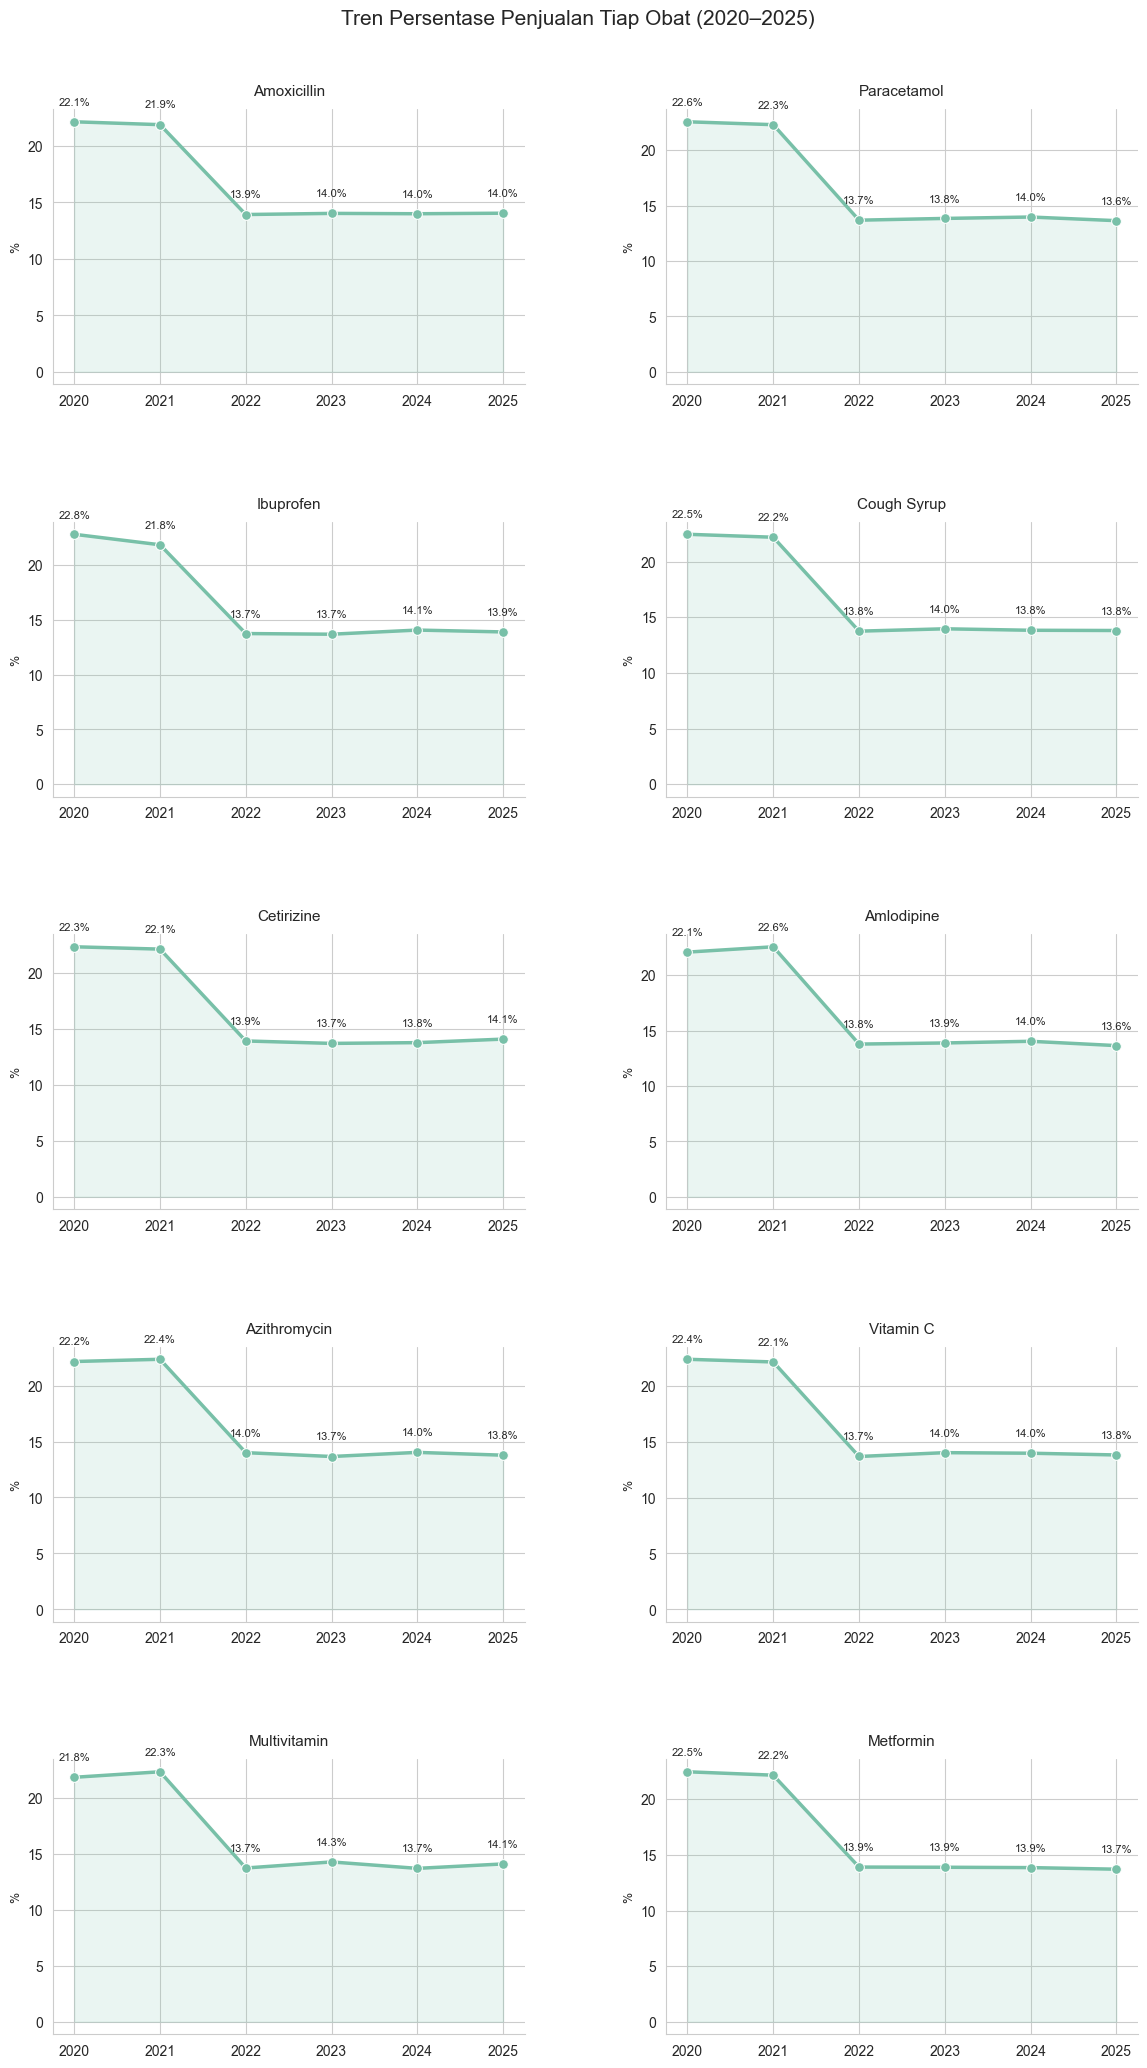

In [19]:
# Mengatur style visualisasi agar menggunakan grid putih
sns.set_style("whitegrid")

# Mengambil daftar unik nama obat
med_list = data_df['medicine'].unique()

# Menentukan jumlah kolom subplot
n_cols = 2

# Menghitung jumlah baris subplot berdasarkan jumlah obat
n_rows = (len(med_list) + n_cols - 1) // n_cols

# Membuat kanvas figure dan subplot
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 5))

# Mengubah axes menjadi array 1 dimensi agar mudah di-loop
axes = axes.flatten()

# Loop untuk setiap obat
for i, med in enumerate(med_list):

    # Filter data untuk 1 obat saja
    df_med = data_df[data_df['medicine'] == med]

    # Menghitung total penjualan per tahun untuk obat tersebut
    trend_med = df_med.groupby('year', as_index=False)['units_sold'].sum()

    # Menghitung total keseluruhan penjualan obat tersebut
    total = trend_med['units_sold'].sum()

    # Mengubah menjadi persentase kontribusi tiap tahun
    trend_med['percentage'] = (trend_med['units_sold'] / total) * 100

    # Membuat line chart tren persentase penjualan per tahun
    sns.lineplot(
        data=trend_med,
        x='year',
        y='percentage',
        marker='o',         # Menampilkan titik di tiap tahun
        linewidth=2.5,      # Ketebalan garis
        markersize=7,       # Ukuran titik
        color='#78C0A8',    # Warna garis
        ax=axes[i]          # Plot ke subplot ke-i
    )

    # Memberi area shading di bawah garis
    axes[i].fill_between(
        trend_med['year'],
        trend_med['percentage'],
        color='#78C0A8',
        alpha=0.15          # Transparansi
    )

    # Menambahkan label persentase di tiap titik
    for x, y in zip(trend_med['year'], trend_med['percentage']):
        axes[i].text(
            x, y + 1.5,     # Menggeser posisi label ke atas agar tidak bertabrakan
            f'{y:.1f}%',
            ha='center',
            fontsize=8
        )

    # Memberi judul subplot sesuai nama obat
    axes[i].set_title(med, fontsize=11, pad=10)

    # Label sumbu Y
    axes[i].set_ylabel('%', fontsize=9)

    # Mengosongkan label sumbu X (biar rapi)
    axes[i].set_xlabel('')

    # Menghilangkan garis atas dan kanan (biar clean)
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

# Menghapus subplot yang tidak terpakai
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Mengatur jarak antar subplot agar tidak terlalu rapat
plt.subplots_adjust(hspace=0.5, wspace=0.3)

# Menambahkan judul utama untuk seluruh figure
plt.suptitle(
    'Tren Persentase Penjualan Tiap Obat (2020–2025)',
    fontsize=15,
    y=0.92
)

# Menampilkan seluruh plot
plt.show()

**Conclusion:**

Berdasarkan visualisasi, terlihat bahwa terjadi peningkatan signifikan pada penjualan obat dari tahun 2020 ke 2021, yang kemungkinan besar dipicu oleh meningkatnya permintaan akibat pandemi COVID-19.

Pada periode setelahnya, yaitu 2021 hingga 2025, tren penjualan menunjukkan pola fluktuatif, namun tetap berada dalam rentang yang relatif stabil. Tidak terdapat lonjakan atau penurunan yang ekstrem seperti yang terjadi pada awal periode pandemi, sehingga dapat disimpulkan bahwa permintaan obat mulai kembali normal setelah tahun 2021.

**Pertanyaan 3: Apakah terdapat pola musiman dalam permintaan obat?**

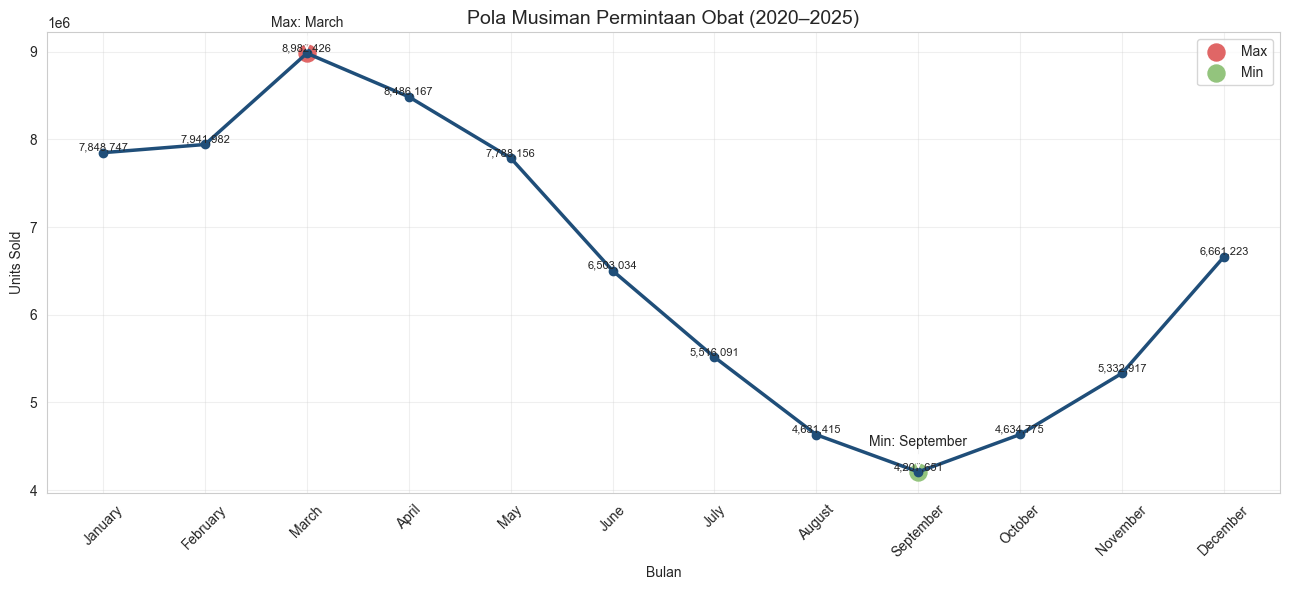

In [20]:
# Membuat ukuran figure untuk visualisasi
plt.figure(figsize=(13,6))

# Membuat garis utama tren penjualan bulanan
plt.plot(
    monthly_demand['month'],
    monthly_demand['units_sold'],
    marker='o',
    linewidth=2.5,
    color='#1F4E79'
)

# Mencari index nilai penjualan maksimum dan minimum
max_idx = monthly_demand['units_sold'].idxmax()
min_idx = monthly_demand['units_sold'].idxmin()

# Menandai titik dengan penjualan tertinggi
plt.scatter(
    monthly_demand.loc[max_idx, 'month'],
    monthly_demand.loc[max_idx, 'units_sold'],
    s=150,
    color='#E06666',
    label='Max'
)

# Menandai titik dengan penjualan terendah
plt.scatter(
    monthly_demand.loc[min_idx, 'month'],
    monthly_demand.loc[min_idx, 'units_sold'],
    s=150,
    color='#93C47D',
    label='Min'
)

# Menambahkan label angka pada setiap titik data
for i, row in monthly_demand.iterrows():
    plt.text(
        i,  # Posisi horizontal berdasarkan index
        row['units_sold'],
        f"{row['units_sold']:,.0f}",  # Format angka dengan pemisah ribuan
        ha='center',
        va='bottom',
        fontsize=8
    )

# Menambahkan anotasi untuk titik maksimum
plt.annotate(
    f"Max: {monthly_demand.loc[max_idx, 'month']}",
    xy=(monthly_demand.loc[max_idx, 'month'], monthly_demand.loc[max_idx, 'units_sold']),
    xytext=(monthly_demand.loc[max_idx, 'month'], monthly_demand.loc[max_idx, 'units_sold'] + 300000),
    arrowprops=dict(arrowstyle='->'),
    ha='center'
)

# Menambahkan anotasi untuk titik minimum
plt.annotate(
    f"Min: {monthly_demand.loc[min_idx, 'month']}",
    xy=(monthly_demand.loc[min_idx, 'month'], monthly_demand.loc[min_idx, 'units_sold']),
    xytext=(monthly_demand.loc[min_idx, 'month'], monthly_demand.loc[min_idx, 'units_sold'] + 300000),
    arrowprops=dict(arrowstyle='->'),
    ha='center'
)

# Memberikan judul pada grafik
plt.title('Pola Musiman Permintaan Obat (2020–2025)', fontsize=14)

# Memberikan label pada sumbu X
plt.xlabel('Bulan')

# Memberikan label pada sumbu Y
plt.ylabel('Units Sold')

# Memutar label bulan agar tidak bertabrakan
plt.xticks(rotation=45)

# Menambahkan grid agar lebih mudah dibaca
plt.grid(alpha=0.3)

# Menampilkan legenda untuk penanda Max dan Min
plt.legend()

# Mengatur layout agar tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

**Conclusion:**

Berdasarkan hasil analisis data penjualan obat periode 2020–2025 yang telah diagregasi per bulan, ditemukan adanya pola musiman (*seasonality*) dalam permintaan obat. Permintaan cenderung meningkat pada awal tahun, mencapai puncaknya pada bulan Maret, kemudian mengalami penurunan secara bertahap hingga mencapai titik terendah pada bulan September, dan kembali meningkat pada akhir tahun.

Selain itu, analisis terhadap rata-rata permintaan menunjukkan bahwa bulan-bulan pada awal dan akhir tahun sebagian besar berada di atas rata-rata (*high demand*), sedangkan bulan-bulan pertengahan tahun berada di bawah rata-rata (low demand). Pola ini menunjukkan adanya fluktuasi yang konsisten dan berulang dalam siklus tahunan, sehingga dapat disimpulkan bahwa permintaan obat tidak bersifat acak, melainkan dipengaruhi oleh faktor musiman.

**Pertanyaan 4: Bagaimana distribusi permintaan obat terhadap faktor yang memengaruhi permintaan obat?**

In [21]:
# Mengelompokkan data berdasarkan negara dan menghitung rata-rata penjualan (units_sold)
country_demand = (
    data_df.groupby('country')['units_sold']
    .mean()
    .reset_index()
    .rename(columns={'units_sold': 'avg_units_sold'})  # Mengganti nama kolom agar lebih jelas
    .sort_values('avg_units_sold', ascending=False)    # Mengurutkan dari yang tertinggi ke terendah
)

# Menghitung total rata-rata penjualan dari semua negara
total_avg = country_demand['avg_units_sold'].sum()

# Menghitung persentase kontribusi tiap negara terhadap total rata-rata penjualan
country_demand['percentage'] = (
    country_demand['avg_units_sold'] / total_avg * 100
).round(3)

# Membulatkan nilai rata-rata penjualan agar lebih rapi
country_demand['avg_units_sold'] = country_demand['avg_units_sold'].round(3)

# Menampilkan tabel hasil akhir
display(country_demand)

,country,avg_units_sold,percentage
16,Uae,452.530,5.318
5,China,452.068,5.312
2,Bangladesh,451.152,5.302
11,New Zealand,450.818,5.298
0,Argentina,449.418,5.281
9,Japan,449.273,5.279
4,Canada,449.127,5.278
7,Germany,448.835,5.274
15,Sri Lanka,448.311,5.268
3,Brazil,448.281,5.268


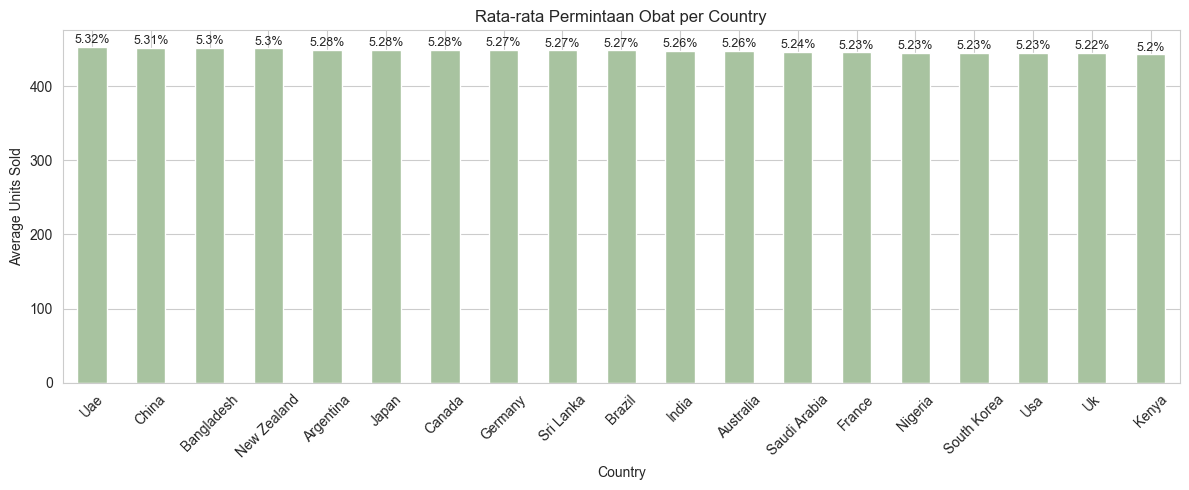

In [22]:
# Mengelompokkan data berdasarkan negara dan menghitung rata-rata penjualan
country_demand = (
    df_analysis.groupby('country')['units_sold']
    .mean()
    .sort_values(ascending=False)  # Mengurutkan dari tertinggi ke terendah
)

# Menghitung persentase kontribusi tiap negara terhadap total rata-rata
percentage = (country_demand / country_demand.sum() * 100).round(2)

# Membuat bar chart untuk rata-rata penjualan per negara
ax = country_demand.plot(
    kind='bar',
    figsize=(12,5),
    color='#A8C3A0'
)

# Menambahkan label persentase di atas setiap bar
for i, value in enumerate(country_demand):
    ax.text(
        i,                # Posisi sumbu X
        value + 1,        # Posisi sedikit di atas bar
        f'{percentage.iloc[i]}%',  # Menampilkan persentase
        ha='center',
        va='bottom',
        fontsize=9
    )

# Menambahkan judul grafik
plt.title('Rata-rata Permintaan Obat per Country')

# Memberikan label pada sumbu X
plt.xlabel('Country')

# Memberikan label pada sumbu Y
plt.ylabel('Average Units Sold')

# Memutar label negara agar tidak bertabrakan
plt.xticks(rotation=45)

# Mengatur layout agar tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

Berdasarkan hasil analisis, faktor country memiliki nilai range tertinggi dibandingkan faktor lainnya. Berdasarkan visualisasi distribusi permintaan obat per country, terlihat bahwa rata-rata units sold antar negara relatif seragam tanpa adanya perbedaan yang mencolok. Temuan ini menunjukkan bahwa meskipun country merupakan faktor dengan pengaruh tertinggi dalam analisis sebelumnya, pengaruh tersebut masih tergolong kecil secara praktis. Dengan demikian, permintaan obat pada dataset ini cenderung stabil dan merata di berbagai negara.

**Pertanyaan 5:Bagaimana distribusi permintaan obat di setiap region?**

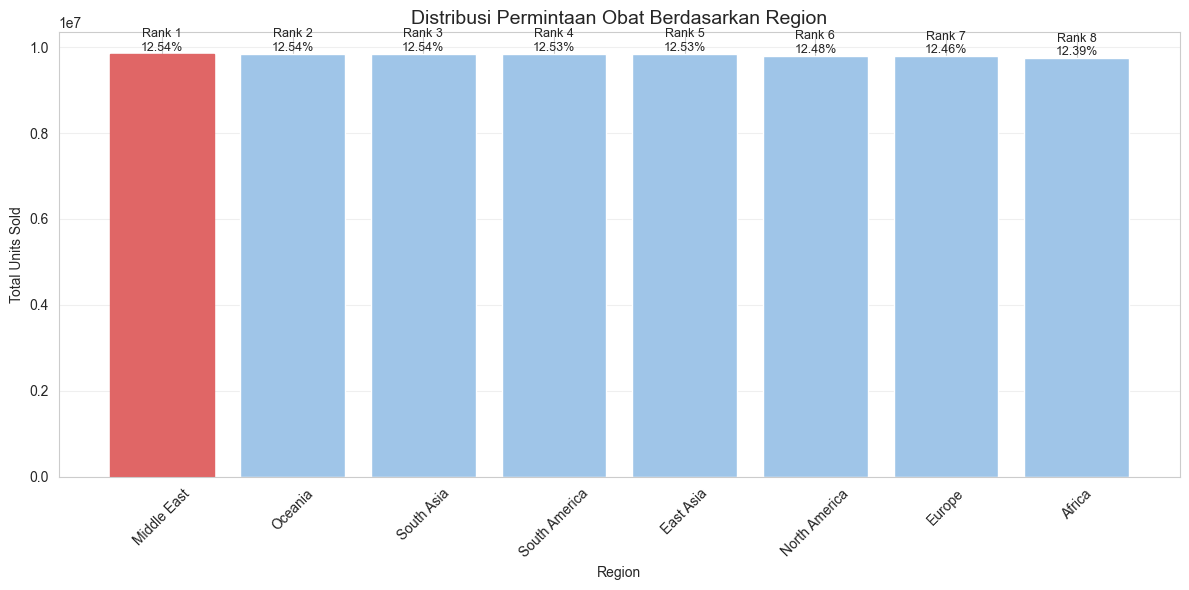

In [ ]:
# Mengurutkan data region berdasarkan total penjualan dari yang tertinggi ke terendah
region_demand = region_demand.sort_values(by='total_units_sold', ascending=False).reset_index(drop=True)

# Membuat ukuran figure untuk visualisasi
plt.figure(figsize=(12,6))

# Membuat bar chart total permintaan obat berdasarkan region
bars = plt.bar(
    region_demand['region'],
    region_demand['total_units_sold'],
    color='#9FC5E8'
)

# Memberi highlight warna berbeda pada region dengan total penjualan tertinggi
bars[0].set_color("#363779")

# Menambahkan label rank dan persentase kontribusi di atas setiap bar
for i, row in enumerate(region_demand.itertuples()):
    plt.text(
        i,  # Posisi bar pada sumbu X
        row.total_units_sold,  # Posisi label di atas tinggi bar
        f"Rank {row.rank}\n{row.persentase_kontribusi}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Memberikan judul grafik
plt.title('Distribusi Permintaan Obat Berdasarkan Region', fontsize=14)

# Memberikan label pada sumbu X
plt.xlabel('Region')

# Memberikan label pada sumbu Y
plt.ylabel('Total Units Sold')

# Memutar label region agar tidak bertabrakan
plt.xticks(rotation=45)

# Menambahkan grid pada sumbu Y agar grafik lebih mudah dibaca
plt.grid(axis='y', alpha=0.3)

# Mengatur layout agar elemen grafik tidak terpotong
plt.tight_layout()

# Menampilkan grafik
plt.show()

**Conclusion:**

Berdasarkan hasil analisis distribusi permintaan obat di berbagai region, ditemukan bahwa permintaan obat relatif merata di seluruh wilayah. Hal ini terlihat dari nilai total penjualan, rata-rata permintaan, serta persentase kontribusi masing-masing region yang berada pada kisaran yang hampir sama, yaitu sekitar 12–13%.

Meskipun terdapat perbedaan ranking antar region, selisih nilai permintaan antar wilayah tidak signifikan, sehingga tidak terdapat region yang secara dominan menguasai permintaan obat. Dengan demikian, dapat disimpulkan bahwa faktor geografis tidak menjadi faktor utama yang memengaruhi variasi permintaan obat.

# **FEATURE ENGINEERING**

In [24]:
# Mengurutkan data berdasarkan nama obat dan tanggal
data_df = data_df.sort_values(['medicine', 'date'])


# Mengubah nama bulan menjadi angka (1–12)
month_mapping = {
    'Januari': 1, 'Februari': 2, 'Maret': 3, 'April': 4,
    'Mei': 5, 'Juni': 6, 'Juli': 7, 'Agustus': 8,
    'September': 9, 'Oktober': 10, 'November': 11, 'Desember': 12
}
data_df['month'] = data_df['month'].map(month_mapping)

# Mengambil informasi waktu dari kolom tanggal
data_df['quarter'] = data_df['date'].dt.quarter   # kuartal (1–4)
data_df['year'] = data_df['date'].dt.year         # tahun

# Menghapus kolom month_num jika ada
data_df = data_df.drop(columns=['month_num'], errors='ignore')


# Membuat fitur lag (nilai penjualan sebelumnya)
data_df['lag_1'] = data_df.groupby('medicine')['units_sold'].shift(1)  # 1 bulan sebelumnya
data_df['lag_3'] = data_df.groupby('medicine')['units_sold'].shift(3)  # 3 bulan sebelumnya


# Menghitung rata-rata penjualan 3 periode sebelumnya (rolling mean)
data_df['rolling_mean_3'] = (
    data_df.groupby('medicine')['units_sold']
    .transform(lambda x: x.shift(1).rolling(3).mean())
)


# Menghitung pertumbuhan penjualan dari periode sebelumnya
data_df['growth_rate'] = (
    data_df.groupby('medicine')['units_sold'].pct_change()
)


# Menghitung perubahan harga dari periode sebelumnya
data_df['price_change'] = (
    data_df.groupby('medicine')['unit_price'].pct_change()
)


# Mengukur coverage stok terhadap penjualan
data_df['coverage'] = (
    data_df['stock_level'] / (data_df['units_sold'] + 1)
)


# Menandai apakah obat mendekati masa kadaluarsa (< 90 hari)
data_df['near_expiry'] = (
    data_df['expiry_days_remaining'] < 90
).astype(int)


# Membersihkan data dari nilai tak hingga dan nilai kosong
data_df = data_df.replace([np.inf, -np.inf], np.nan)
data_df = data_df.dropna()


# Mengatur tampilan dataframe agar semua kolom terlihat
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Menampilkan 5 baris pertama
display(data_df.head())

,date,year,month,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,quarter,lag_1,lag_3,rolling_mean_3,growth_rate,price_change,coverage,near_expiry
42,2020-01-01,2020,1,South America,Argentina,Chronic,Amlodipine,46-65,967,21.75,3964,498,1,897.0,672.0,751.000000,0.078038,1.749684,4.095041,0
52,2020-01-01,2020,1,South Asia,India,Chronic,Amlodipine,46-65,913,89.75,3932,559,1,967.0,684.0,849.333333,-0.055843,3.126437,4.301969,0
61,2020-01-01,2020,1,Europe,France,Chronic,Amlodipine,46-65,868,26.46,3971,389,1,913.0,897.0,925.666667,-0.049288,-0.705181,4.569620,0
62,2020-01-01,2020,1,North America,Usa,Chronic,Amlodipine,0-12,485,16.78,4694,504,1,868.0,967.0,916.000000,-0.441244,-0.365835,9.658436,0
67,2020-01-01,2020,1,Africa,Kenya,Chronic,Amlodipine,46-65,912,83.40,4240,435,1,485.0,913.0,755.333333,0.880412,3.970203,4.644031,0


In [25]:
data_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175330 entries, 42 to 177973
Data columns (total 20 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   date                   175330 non-null  datetime64[ns]
 1   year                   175330 non-null  int32         
 2   month                  175330 non-null  int64         
 3   region                 175330 non-null  object        
 4   country                175330 non-null  object        
 5   category               175330 non-null  object        
 6   medicine               175330 non-null  object        
 7   age_group              175330 non-null  object        
 8   units_sold             175330 non-null  int64         
 9   unit_price             175330 non-null  float64       
 10  stock_level            175330 non-null  int64         
 11  expiry_days_remaining  175330 non-null  int64         
 12  quarter                175330 non-null  int32   

In [26]:
# ENCODING

# Menentukan kolom kategori yang akan diubah menjadi numerik
categorical_cols = ['region', 'country', 'category', 'medicine', 'age_group']

# Menyimpan encoder untuk setiap kolom (biar bisa dipakai lagi nanti)
label_encoders = {}

# Loop untuk setiap kolom kategori
for col in categorical_cols:
    le = LabelEncoder()  # Membuat objek encoder
    data_df[col] = le.fit_transform(data_df[col])  # Mengubah kategori jadi angka
    label_encoders[col] = le  # Menyimpan encoder

# Menampilkan hasil setelah encoding
display(data_df.head())

,date,year,month,region,country,category,medicine,age_group,units_sold,unit_price,stock_level,expiry_days_remaining,quarter,lag_1,lag_3,rolling_mean_3,growth_rate,price_change,coverage,near_expiry
42,2020-01-01,2020,1,6,0,2,0,3,967,21.75,3964,498,1,897.0,672.0,751.000000,0.078038,1.749684,4.095041,0
52,2020-01-01,2020,1,7,8,2,0,3,913,89.75,3932,559,1,967.0,684.0,849.333333,-0.055843,3.126437,4.301969,0
61,2020-01-01,2020,1,2,6,2,0,3,868,26.46,3971,389,1,913.0,897.0,925.666667,-0.049288,-0.705181,4.569620,0
62,2020-01-01,2020,1,4,18,2,0,0,485,16.78,4694,504,1,868.0,967.0,916.000000,-0.441244,-0.365835,9.658436,0
67,2020-01-01,2020,1,0,10,2,0,3,912,83.40,4240,435,1,485.0,913.0,755.333333,0.880412,3.970203,4.644031,0


In [27]:
data_df.to_csv('data_feature_engineering.csv', index=False)